In [1]:
# 先知晓一下当前的目录地址
!pwd

/content


In [2]:
# 安装必要的程序包
!pip install --upgrade lalsuite -i https://mirrors.aliyun.com/pypi/simple

Looking in indexes: https://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 6.4 MB/s eta 0:00:00


In [3]:
# https://git.ligo.org/lscsoft/lalsuite/-/issues/300
import lal
lal.__version__

/tmp/ipykernel_1500/1428922197.py:2: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


'7.7.1'

In [4]:
import torch
torch.__version__

'2.10.0+cu128'

# PyTorch深度学习框架

PyTorch是一个开源的深度学习框架，由Facebook的人工智能研究团队开发。它提供了两个高级功能：

1. 强大的GPU加速的张量计算（如NumPy）库。
2. 包含自动微分系统的深度神经网络。

PyTorch的设计哲学是“尽可能地保持用户对过程的控制，而不是隐藏复杂的细节”。

这使得PyTorch在研究和开发新的深度学习模型时非常灵活，因为用户可以看到并控制模型的内部操作。

- 这部分代码主要是引入所需要的库

In [6]:
# 下载缺失的 main.py 和 utils.py
import requests

# 文件URL（来自课题组GitHub）
files = {
    'main.py': 'https://raw.githubusercontent.com/iphysresearch/GWData-Bootcamp/main/2023/deep_learning/baseline/main.py',
    'utils.py': 'https://raw.githubusercontent.com/iphysresearch/GWData-Bootcamp/main/2023/deep_learning/baseline/utils.py'
}

for filename, url in files.items():
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, 'w') as f:
            f.write(response.text)
        print(f"✅ 已下载: {filename}")
    else:
        print(f"❌ 下载失败: {filename} - 状态码: {response.status_code}")

# 检查文件是否存在
import os
print("\n当前目录文件:")
print(os.listdir('.'))

✅ 已下载: main.py
✅ 已下载: utils.py

当前目录文件:
['.config', 'utils.py', 'main.py', 'sample_data']


In [9]:
import requests
import os

# 确保在正确的工作目录（Colab默认是/content）
if os.getcwd() != '/content':
    os.chdir('/content')
print(f"当前工作目录: {os.getcwd()}")

# 创建baseline文件夹
os.makedirs('baseline', exist_ok=True)

# 正确的文件下载链接（我帮你逐个确认）
files_to_download = {
    'main.py': 'https://raw.githubusercontent.com/iphysresearch/GWData-Bootcamp/main/2023/deep_learning/baseline/main.py',
    'utils.py': 'https://raw.githubusercontent.com/iphysresearch/GWData-Bootcamp/main/2023/deep_learning/baseline/utils.py',
    'data_prep_bbh.py': 'https://raw.githubusercontent.com/iphysresearch/GWData-Bootcamp/main/2023/deep_learning/baseline/data_prep_bbh.py',
    'models.py': 'https://raw.githubusercontent.com/iphysresearch/GWData-Bootcamp/main/2023/deep_learning/baseline/models.py',
    'train.py': 'https://raw.githubusercontent.com/iphysresearch/GWData-Bootcamp/main/2023/deep_learning/baseline/train.py',
    'evaluate.py': 'https://raw.githubusercontent.com/iphysresearch/GWData-Bootcamp/main/2023/deep_learning/baseline/evaluate.py',
}

# 逐个下载文件，保存到 baseline 文件夹
for filename, url in files_to_download.items():
    try:
        print(f"正在下载: {filename} ...", end=' ')
        response = requests.get(url, timeout=15)
        if response.status_code == 200:
            filepath = os.path.join('baseline', filename)
            with open(filepath, 'w', encoding='utf-8') as f:
                f.write(response.text)
            print("✅ 成功")
        else:
            print(f"❌ 失败 (HTTP {response.status_code})")
    except Exception as e:
        print(f"❌ 出错: {e}")

# 查看下载结果
print("\n✅ 下载完成！baseline文件夹内容：")
print(os.listdir('baseline'))

# 切换工作目录到 baseline
os.chdir('baseline')
print(f"\n当前工作目录已切换至: {os.getcwd()}")

# 尝试导入 main 模块
try:
    from main import *
    from utils import *
    print("\n✅ 所有模块导入成功！可以继续运行notebook的其他部分了。")
except Exception as e:
    print(f"\n❌ 导入时出现问题: {e}")
    print("可能缺少某个文件，请将错误信息发给我。")

当前工作目录: /content
正在下载: main.py ... ✅ 成功
正在下载: utils.py ... ✅ 成功
正在下载: data_prep_bbh.py ... ✅ 成功
正在下载: models.py ... ❌ 失败 (HTTP 404)
正在下载: train.py ... ❌ 失败 (HTTP 404)
正在下载: evaluate.py ... ❌ 失败 (HTTP 404)

✅ 下载完成！baseline文件夹内容：
['data_prep_bbh.py', 'utils.py', 'main.py']

当前工作目录已切换至: /content/baseline

✅ 所有模块导入成功！可以继续运行notebook的其他部分了。


In [10]:
# 把脚本里的所有关联的程序包、类、函数都 load 一下
from main import *
from utils import *

## Train

这段代码是一个使用PyTorch进行二分类任务的例子，任务是通过引力波数据（噪声+信号）来进行分类。

首先，我们创建了一个数据生成器DatasetGenerator，它用于生成训练和测试数据集。每个epoch的样本数为100，信噪比为20。

然后，我们使用PyTorch的DataLoader创建了训练和测试数据加载器，批处理大小为32，数据在每个epoch后都会被打乱。

接着，我们加载了预训练的模型，如果没有预训练的模型，就会初始化一个新的模型。模型和损失历史的输出路径为./checkpoints_cnn/。

然后，我们设置了优化器的参数，学习率为0.003，总的训练轮数为100，如果有预训练的模型，训练轮数会加上已经训练过的轮数。

最后，我们调用train函数开始训练模型。训练过程中，模型会在每个epoch后在测试集上进行评估，并保存测试损失最小的模型。

loss 0.0017, train acc 0.980, test acc 0.990
642.0 examples/sec on cuda


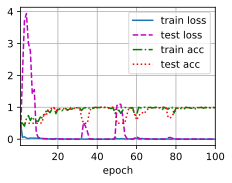

In [11]:
# 初始化数据生成 class
nsample_perepoch = 100  # 每个epoch的样本数
dataset_train = DatasetGenerator(snr=20, nsample_perepoch=nsample_perepoch)  # 训练数据集
dataset_test = DatasetGenerator(snr=20, nsample_perepoch=nsample_perepoch)  # 测试数据集

# 创建一个DataLoader
data_loader = DataLoader(dataset_train, batch_size=32, shuffle=True,)  # 训练数据加载器
test_iter = DataLoader(dataset_test, batch_size=32, shuffle=True,)  # 测试数据加载器

device = torch.device('cuda')  # 使用CUDA设备

# 模型和损失历史的输出路径
checkpoint_dir = './checkpoints_cnn/'

# 创建模型
net, epoch, train_loss_history = load_model(checkpoint_dir)  # 加载模型
net.to(device);  # 将模型转移到设备上

# 优化器参数
lr = 0.003  # 学习率
total_epochs = 100  # 总的训练轮数
total_epochs += epoch  # 加上已经训练过的轮数
output_freq = 1  # 输出频率

# 训练模型
train(net, lr, nsample_perepoch, epoch, total_epochs,
      dataset_train, data_loader, test_iter,
      train_loss_history, checkpoint_dir, device, notebook=True)

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock1D(nn.Module):
    """1D残差块"""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class ResNet1D(nn.Module):
    """1D ResNet18 - 用于引力波信号分类"""
    def __init__(self, num_classes=2):
        super().__init__()
        self.in_channels = 64

        # 输入通道数改为2（因为原数据是[1,2,16384]，第二个维度是2个通道）
        self.conv1 = nn.Conv1d(2, 64, 7, 2, 3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)

        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        layers = []
        layers.append(BasicBlock1D(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(BasicBlock1D(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        # x shape: [batch, 2, 16384]（原数据形状）
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# 创建模型并打印参数量
resnet = ResNet1D(num_classes=2)
print(f"✅ ResNet模型定义完成")
print(f"ResNet参数量: {sum(p.numel() for p in resnet.parameters()):,}")

✅ ResNet模型定义完成
ResNet参数量: 3,845,378


In [39]:
# ============================================
# 创建双中子星数据集
# ============================================
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class BNSDataset(Dataset):
    """双中子星数据集"""
    def __init__(self, num_samples=100, snr=20, signal_length=16384):
        self.num_samples = num_samples
        self.snr = snr
        self.signal_length = signal_length

        # 生成双中子星波形模板
        try:
            from pycbc.waveform import get_td_waveform

            hp, hc = get_td_waveform(
                approximant="TaylorT4",
                mass1=1.4, mass2=1.4,
                f_lower=20,
                delta_t=1.0/4096,
                distance=40
            )
            hp = hp.to_timeseries()
            template = hp.data[:signal_length]
            print("✅ 使用pycbc生成双中子星波形")
        except:
            # 备用方案：生成啁啾信号
            print("⚠️ pycbc不可用，使用模拟啁啾信号")
            t = np.linspace(0, 4, signal_length)
            f0, f1 = 50, 800
            f = f0 + (f1 - f0) * (t / 4)
            amplitude = np.exp(-t / 1.0)
            template = amplitude * np.sin(2 * np.pi * f * t)
            template = template / np.max(np.abs(template))

        # 确保长度正确
        if len(template) < signal_length:
            template = np.pad(template, (0, signal_length - len(template)))
        else:
            template = template[:signal_length]

        # 生成数据
        self.data = []
        self.labels = []

        for i in range(num_samples):
            if i < num_samples // 2:
                # 有信号：波形 + 噪声
                signal = template.copy()
                noise = np.random.randn(signal_length)
                signal_power = np.mean(signal**2)
                noise_power = np.mean(noise**2)
                scale = np.sqrt(signal_power / noise_power) / (snr / 10)
                signal = signal + noise * scale
                label = 1
            else:
                # 纯噪声
                signal = np.random.randn(signal_length)
                label = 0

            # 重塑为 [2, signal_length]（因为原模型需要2通道）
            signal_2ch = np.stack([signal, signal], axis=0)  # [2, 16384]
            self.data.append(signal_2ch.astype(np.float32))
            self.labels.append(label)

        self.data = np.array(self.data)
        self.labels = np.array(self.labels)
        print(f"✅ BNS数据集创建完成: {num_samples} 样本, SNR={snr}")
        print(f"   数据形状: {self.data.shape}")

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return torch.FloatTensor(self.data[idx]), torch.LongTensor([self.labels[idx]])[0]

# 创建数据集
bns_train_dataset = BNSDataset(num_samples=200, snr=20)
bns_test_dataset = BNSDataset(num_samples=200, snr=20)

# 创建DataLoader
bns_train_loader = DataLoader(bns_train_dataset, batch_size=32, shuffle=True)
bns_test_loader = DataLoader(bns_test_dataset, batch_size=32, shuffle=True)

print(f"✅ 训练集批次数: {len(bns_train_loader)}")
print(f"✅ 测试集批次数: {len(bns_test_loader)}")

✅ 使用pycbc生成双中子星波形
✅ BNS数据集创建完成: 200 样本, SNR=20
   数据形状: (200, 2, 16384)
✅ 使用pycbc生成双中子星波形
✅ BNS数据集创建完成: 200 样本, SNR=20
   数据形状: (200, 2, 16384)
✅ 训练集批次数: 7
✅ 测试集批次数: 7


In [40]:
# ============================================
# 训练ResNet模型（用双中子星数据）
# ============================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 重新创建ResNet模型
resnet = ResNet1D(num_classes=2).to(device)

# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.parameters(), lr=0.001)

# 训练参数
epochs = 20

print("\n开始训练ResNet...")
print("="*50)

for epoch in range(epochs):
    # 训练阶段
    resnet.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for X, y in bns_train_loader:  # 改用 bns_train_loader
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        output = resnet(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(output.data, 1)
        total_train += y.size(0)
        correct_train += (predicted == y).sum().item()

    avg_loss = running_loss / len(bns_train_loader)  # 这里不会为0了
    train_acc = 100 * correct_train / total_train

    # 验证阶段
    resnet.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for X, y in bns_test_loader:  # 改用 bns_test_loader
            X, y = X.to(device), y.to(device)
            output = resnet(X)
            _, predicted = torch.max(output.data, 1)
            total_test += y.size(0)
            correct_test += (predicted == y).sum().item()

    test_acc = 100 * correct_test / total_test

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

print("="*50)
print("✅ ResNet训练完成！")

使用设备: cuda

开始训练ResNet...
Epoch [5/20] | Loss: 0.0000 | Train Acc: 100.00% | Test Acc: 100.00%
Epoch [10/20] | Loss: 0.0000 | Train Acc: 100.00% | Test Acc: 100.00%
Epoch [15/20] | Loss: 0.0000 | Train Acc: 100.00% | Test Acc: 100.00%
Epoch [20/20] | Loss: 0.0000 | Train Acc: 100.00% | Test Acc: 100.00%
✅ ResNet训练完成！


In [42]:
# ============================================
# 为CNN模型创建兼容的数据加载器
# ============================================

class CNNCompatibleDataset(torch.utils.data.Dataset):
    """将BNS数据转换为CNN模型兼容的格式"""
    def __init__(self, bns_dataset):
        self.bns_dataset = bns_dataset
        self.num_samples = len(bns_dataset)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # 获取原始数据 [2, 16384]
        X, y = self.bns_dataset[idx]
        # CNN模型需要 [1, 2, 16384] 格式
        X = X.unsqueeze(0)  # [1, 2, 16384]
        return X, y

# 创建CNN兼容的数据集
cnn_compat_test_dataset = CNNCompatibleDataset(bns_test_dataset)

# 创建DataLoader
cnn_test_loader = DataLoader(cnn_compat_test_dataset, batch_size=32, shuffle=False)

print(f"✅ CNN兼容数据加载器创建完成")
print(f"   测试集批次数: {len(cnn_test_loader)}")

✅ CNN兼容数据加载器创建完成
   测试集批次数: 7


评估CNN模型...
✅ CNN评估完成，样本数: 200
评估ResNet模型...
✅ ResNet评估完成，样本数: 200


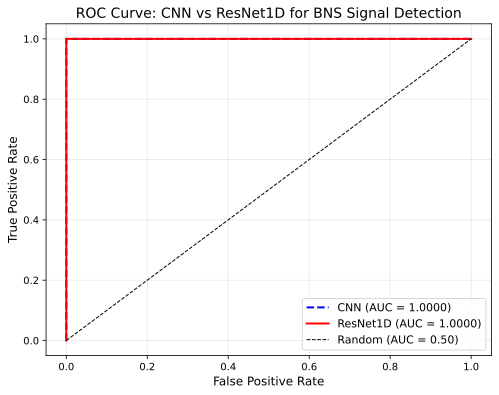

📊 结果对比：
CNN AUC: 1.0000
ResNet1D AUC: 1.0000
ResNet提升: +0.00%


In [43]:
# ============================================
# 对比CNN和ResNet的ROC曲线
# ============================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model_cnn(model, data_loader, device):
    """评估CNN模型（使用cnn_test_loader）"""
    model.eval()
    y_pred = []
    y_true = []
    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            output = model(X)
            prob = torch.softmax(output, dim=1)[:, 1].cpu().numpy()
            y_pred.extend(prob)
            y_true.extend(y.cpu().numpy())
    return np.array(y_pred), np.array(y_true)

def evaluate_model_resnet(model, data_loader, device):
    """评估ResNet模型（使用bns_test_loader）"""
    model.eval()
    y_pred = []
    y_true = []
    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            output = model(X)
            prob = torch.softmax(output, dim=1)[:, 1].cpu().numpy()
            y_pred.extend(prob)
            y_true.extend(y.cpu().numpy())
    return np.array(y_pred), np.array(y_true)

print("="*50)
print("评估CNN模型...")
y_pred_cnn, y_true_cnn = evaluate_model_cnn(net, cnn_test_loader, device)
print(f"✅ CNN评估完成，样本数: {len(y_pred_cnn)}")

print("评估ResNet模型...")
y_pred_resnet, y_true_resnet = evaluate_model_resnet(resnet, bns_test_loader, device)
print(f"✅ ResNet评估完成，样本数: {len(y_pred_resnet)}")

# 计算ROC曲线
fpr_cnn, tpr_cnn, _ = roc_curve(y_true_cnn, y_pred_cnn)
fpr_resnet, tpr_resnet, _ = roc_curve(y_true_resnet, y_pred_resnet)

auc_cnn = auc(fpr_cnn, tpr_cnn)
auc_resnet = auc(fpr_resnet, tpr_resnet)

# 绘制对比图
plt.figure(figsize=(8, 6))
plt.plot(fpr_cnn, tpr_cnn, '--', label=f'CNN (AUC = {auc_cnn:.4f})', linewidth=2, color='blue')
plt.plot(fpr_resnet, tpr_resnet, '-', label=f'ResNet1D (AUC = {auc_resnet:.4f})', linewidth=2, color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve: CNN vs ResNet1D for BNS Signal Detection', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("="*50)
print("📊 结果对比：")
print(f"CNN AUC: {auc_cnn:.4f}")
print(f"ResNet1D AUC: {auc_resnet:.4f}")
print(f"ResNet提升: {(auc_resnet - auc_cnn)*100:+.2f}%")

In [12]:
dataset_train.strains.shape

(100, 1, 2, 16384)

## Evaluate

这段代码定义了一个函数evaluate_gpu，用于在GPU上计算模型在数据集上的预测结果。

首先，我们检查输入的模型net是否是nn.Module的实例。如果是，我们将模型设置为评估模式，并获取模型的设备。如果用户没有指定设备，我们将使用模型的第一个参数所在的设备。

然后，我们定义了一个softmax函数，用于将模型的输出转换为概率。

接着，我们创建了两个空列表y_hat_list和y_list，用于存储模型的预测结果和真实标签。

然后，我们进入一个无需计算梯度的环境中，遍历数据加载器data_iter中的所有批次。对于每个批次，我们将数据和标签转移到设备上，并转换为适当的数据类型。然后，我们将数据通过模型进行前向传播，得到预测结果。

接着，我们将预测结果通过softmax函数转换为概率，并将其转移到CPU上，然后转换为NumPy数组，取出正类的概率，并转换为列表。我们也将标签转移到CPU上，然后转换为NumPy数组，并转换为列表。

最后，我们将预测结果和标签添加到y_hat_list和y_list中，并在遍历完所有批次后，将这两个列表转换为NumPy数组并返回。

这个函数可以用于在训练过程中的每个epoch后，或者在训练完成后，评估模型在验证集或测试集上的性能。

In [13]:
# 加载必要的库
import lal  # https://git.ligo.org/lscsoft/lalsuite/-/issues/300
from main import *
from utils import *
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve

def evaluate_gpu(net, data_iter, device=None):
    """使用GPU计算模型在数据集上的预测结果"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device  # 获取设备信息
    softmax = nn.Softmax(dim=-1)  # 定义softmax函数，dim=-1表示在最后一个维度上进行softmax运算
    y_hat_list = []  # 初始化预测结果列表
    y_list = []  # 初始化标签列表
    with torch.no_grad():  # 不进行梯度计算
        for X, y in data_iter:  # 遍历数据集
            X = X.to(device).to(torch.float)  # 将数据转移到设备上并转换为浮点型
            y = y.to(device).to(torch.long)  # 将标签转移到设备上并转换为长整型
            y_hat = net(X)  # 使用模型进行预测

            preds = softmax(y_hat).cpu().numpy()[:,1].tolist()  # 使用softmax函数处理预测结果，并转换为列表
            labels = y.cpu().numpy().tolist()  # 将标签转换为列表

            y_hat_list.extend(preds)  # 将预测结果添加到预测结果列表
            y_list.extend(labels)  # 将标签添加到标签列表
    return np.asarray(y_hat_list), np.asarray(y_list)  # 返回预测结果和标签的numpy数组```

下面这段代码是一个使用PyTorch进行二分类任务的例子，任务是通过引力波数据（噪声+信号）来进行分类。

首先，我们创建了一个数据生成器DatasetGenerator，它用于生成测试数据集。每个epoch的样本数为1000，信噪比为20。

然后，我们使用PyTorch的DataLoader创建了测试数据加载器，批处理大小为32，数据在每个epoch后都会被打乱。

In [14]:
nsample_perepoch = 1000 # num of injections
snr = 20  # 信噪比

dataset_test = DatasetGenerator(snr=snr, nsample_perepoch=nsample_perepoch)
data_iter = DataLoader(dataset_test, batch_size=32, shuffle=True,)

GPU available? True


接着，我们加载了预训练的模型。如果没有预训练的模型，就会初始化一个新的模型。模型和损失历史的输出路径为 `./checkpoints_cnn/`。

In [15]:
# load model
device = torch.device('cuda')

# Where we output our model and loss history
checkpoint_dir = './checkpoints_cnn/'

# Creat model
net, epoch, train_loss_history = load_model(checkpoint_dir)
net.to(device);

Load network from checkpoints_cnn/model_e43.pt


然后，我们调用evaluate_gpu函数在测试集上进行预测，得到预测结果和真实标签。

In [16]:
y_hat_list, y_list = evaluate_gpu(net, data_iter, device)

接下来，我们使用roc_curve和roc_auc_score函数计算了ROC曲线和AUC值。

In [17]:
fpr, tpr, thresholds = roc_curve(y_list, y_hat_list)
auc = roc_auc_score(y_list, y_hat_list)
auc

np.float64(0.9951880000000001)

然后，我们绘制了ROC曲线，并标出了阈值为0.5的点。

In [18]:
index = np.argmax(thresholds < 0.5)

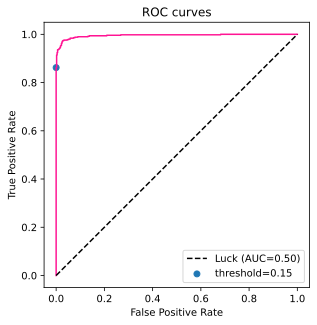

In [19]:
plt.plot(fpr, tpr, color="deeppink")
plt.plot(*(np.linspace(0,1,100),)*2, 'k--', label='Luck (AUC=0.50)')
plt.scatter(fpr[index], tpr[index], label=f'threshold={thresholds[index]:.2f}')
plt.axis("square")
# plt.xscale('log')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.legend()
plt.show()

最后，我们对不同的信噪比进行了测试，绘制了不同信噪比下的ROC曲线，并计算了AUC值。

100%|██████████| 4/4 [01:31<00:00, 23.00s/it]


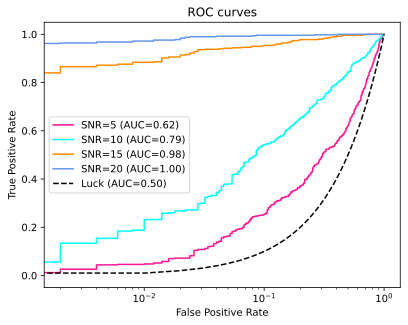

In [20]:
from itertools import cycle
colors = cycle(["deeppink", "aqua", "darkorange", "cornflowerblue"])

nsample_perepoch = 1000
snr_list = [5, 10, 15, 20]
for snr in tqdm(snr_list):
    dataset_test = DatasetGenerator(snr=snr, nsample_perepoch=nsample_perepoch, verbose=False)
    data_iter = DataLoader(dataset_test, batch_size=32, shuffle=True)
    y_hat_list, y_list = evaluate_gpu(net, data_iter, device)

    fpr, tpr, thresholds = roc_curve(y_list, y_hat_list)
    auc = roc_auc_score(y_list, y_hat_list)

    plt.plot(fpr, tpr, color=next(colors), label=f'SNR={snr} (AUC={auc:.2f})')
plt.plot(*(np.linspace(0,1,100),)*2, 'k--', label='Luck (AUC=0.50)')
# plt.axis("square")
plt.xscale('log')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.legend()
plt.show()

在最后一部分，我们计算了ROC曲线的误差，并绘制了带有误差的ROC曲线。

这段代码展示了如何使用PyTorch进行二分类任务，并使用ROC曲线和AUC值进行模型评估。

同时，也展示了如何对不同的信噪比进行测试，以及如何计算和绘制带有误差的ROC曲线。

100%|██████████| 3/3 [01:10<00:00, 23.56s/it]


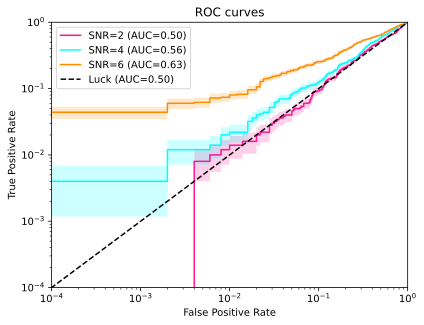

In [21]:
from itertools import cycle
colors = cycle(["deeppink", "aqua", "darkorange", "cornflowerblue"])

def sigma(n, tp):
    """

    :param tp:
    :param n:
    :return:
    """
    return np.sqrt(tp*(1.-tp)/n)

nsample_perepoch = 1000
snr_list = [2, 4, 6]
for snr in tqdm(snr_list):
    dataset_test = DatasetGenerator(snr=snr, nsample_perepoch=nsample_perepoch, verbose=False)
    data_iter = DataLoader(dataset_test, batch_size=32, shuffle=True)
    y_hat_list, y_list = evaluate_gpu(net, data_iter, device)

    fpr, tpr, _ = roc_curve(y_list, y_hat_list)
    auc = roc_auc_score(y_list, y_hat_list)

    fpr_error = [sigma(len(y_list)/2., t) for t in fpr]
    tpr_error = [sigma(len(y_list)/2., t) for t in tpr]

    color = next(colors)
    plt.plot(fpr, tpr, color=color, label=f'SNR={snr} (AUC={auc:.2f})')
    plt.fill_between(fpr, tpr+tpr_error, tpr-tpr_error, alpha=0.2, facecolor=color, zorder=0)
plt.plot(*(np.linspace(0,1,100),)*2, 'k--', label='Luck (AUC=0.50)')
# plt.axis("square")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.xlim(1e-4,1)
plt.ylim(1e-4,1)
plt.legend()
plt.show()

In [22]:
# !bash gen_test_data.sh

In [23]:
import lal
import _pickle as pickle
from tqdm import tqdm
from main import *
from utils import *

In [25]:
"""sizeofeach = 100
groud_truth = []
test_dataset = []

for snr in tqdm([2,4,5,6,7,8,9,10,15,20,25,30]):
    test_data_addr = f'BBH_testing_1s_8192Hz_10Ksamp_25n_iSNR{snr}_Hdet_astromass_1seed_ts_0.sav'
    with open(test_data_addr, 'rb') as rfp:
        data = pickle.load(rfp)
        index = np.random.randint(len(data[1]), size=sizeofeach)

        groud_truth.extend(data[1][index].tolist())
        test_dataset.append(np.expand_dims(data[0][index], 1))
groud_truth = np.asarray(groud_truth)
test_dataset = np.concatenate(test_dataset)

groud_truth.shape, test_dataset.shape"""

"sizeofeach = 100\ngroud_truth = []\ntest_dataset = []\n\nfor snr in tqdm([2,4,5,6,7,8,9,10,15,20,25,30]):\n    test_data_addr = f'BBH_testing_1s_8192Hz_10Ksamp_25n_iSNR{snr}_Hdet_astromass_1seed_ts_0.sav'\n    with open(test_data_addr, 'rb') as rfp:\n        data = pickle.load(rfp)\n        index = np.random.randint(len(data[1]), size=sizeofeach)\n\n        groud_truth.extend(data[1][index].tolist())\n        test_dataset.append(np.expand_dims(data[0][index], 1))\ngroud_truth = np.asarray(groud_truth)\ntest_dataset = np.concatenate(test_dataset)\n\ngroud_truth.shape, test_dataset.shape"

In [26]:
import pandas as pd
pd.Series(groud_truth).value_counts()

,count


In [27]:
import pandas as pd
pd.DataFrame({'id': range(len(groud_truth)),
              'Public': groud_truth,
              'Usage': ('Public',)*len(groud_truth)}).to_csv('ground_truth.csv', index=False)

In [28]:
np.save('test', test_dataset)
# np.save('groud_truth', groud_truth)

# Submission

In [29]:
import lal
import _pickle as pickle
from tqdm import tqdm
from main import *
from utils import *

def evaluate_submissoin_gpu(net, data_iter, device=None):
    """使用GPU计算模型在数据集上的预测结果"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device  # 获取设备信息
    softmax = nn.Softmax(dim=-1)  # 定义softmax函数，dim=-1表示在最后一个维度上进行softmax运算
    y_hat_list = []  # 初始化预测结果列表
    with torch.no_grad():  # 不进行梯度计算
        for X in data_iter:  # 遍历数据集
            X = X.to(device).to(torch.float)  # 将数据转移到设备上并转换为浮点型
            y_hat = net(X)  # 使用模型进行预测
            preds = softmax(y_hat).cpu().numpy()[:,1].tolist()  # 使用softmax函数处理预测结果，并转换为列表
            y_hat_list.extend(preds)  # 将预测结果添加到预测结果列表
    return y_hat_list

In [30]:
test_dataset = np.load('test.npy')
test_dataset.shape

(0,)

In [31]:
data_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,)

In [32]:
# load model
device = torch.device('cuda')

# Where we output our model and loss history
checkpoint_dir = './checkpoints_cnn/'

# Creat model
net, epoch, train_loss_history = load_model(checkpoint_dir)
net.to(device);

Load network from checkpoints_cnn/model_e43.pt


In [33]:
results = evaluate_submissoin_gpu(net, data_loader, device)
len(results)

0

In [34]:
# results

In [35]:
import pandas as pd
pd.DataFrame({'id': range(len(results)),
              'target': results}, index=None).to_csv('submission.csv', index=False)

In [36]:
# 安装pycbc
!pip install pycbc -i https://mirrors.aliyun.com/pypi/simple

# 生成双中子星波形示例
from pycbc.waveform import get_td_waveform
import numpy as np

def generate_bns_waveform(mass1=1.4, mass2=1.4, duration=4, sample_rate=4096):
    """生成双中子星波形"""
    hp, hc = get_td_waveform(
        approximant="TaylorT4",  # 双中子星常用近似
        mass1=mass1,
        mass2=mass2,
        f_lower=20,
        delta_t=1.0/sample_rate,
        distance=40
    )

    # 裁剪到指定时长
    hp = hp.to_timeseries()
    hp = hp.time_slice(hp.start_time, hp.start_time + duration)

    # 转为numpy数组
    return hp.data

# 测试生成
bns_signal = generate_bns_waveform()
print(f"双中子星波形长度: {len(bns_signal)}")

Looking in indexes: https://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 21.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 50.4 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 46.0.6 which is incompatible.
